Q1

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Dataset Path: /kaggle/input/eergy-efficiency-dataset
Files: ['ENB2012_data.csv']

Dataset Shape: (768, 10)
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Heating Load (Y1)
R² = 0.9978
RMSE = 0.474

Cooling Load (Y2)
R² = 0.9805
RMSE = 1.3443


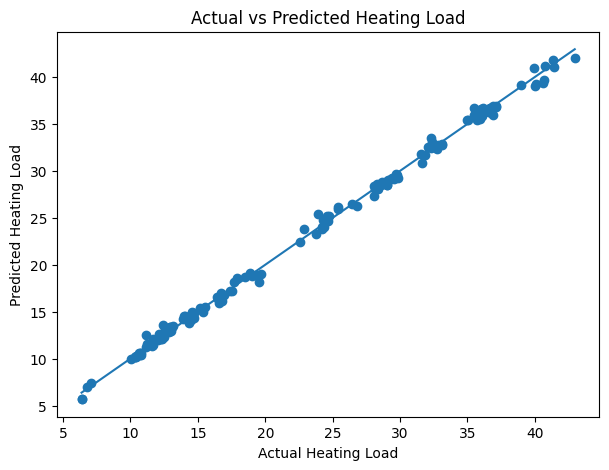

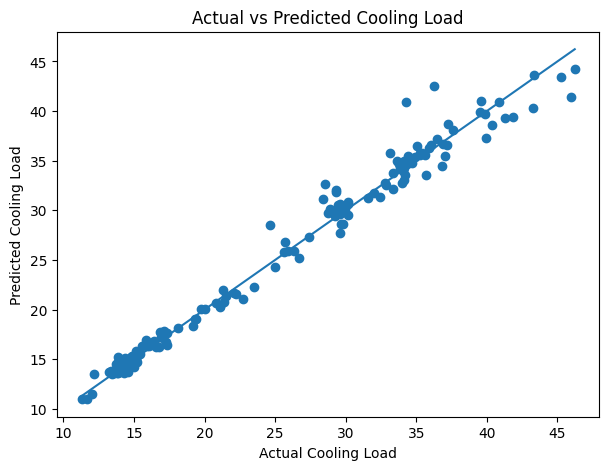

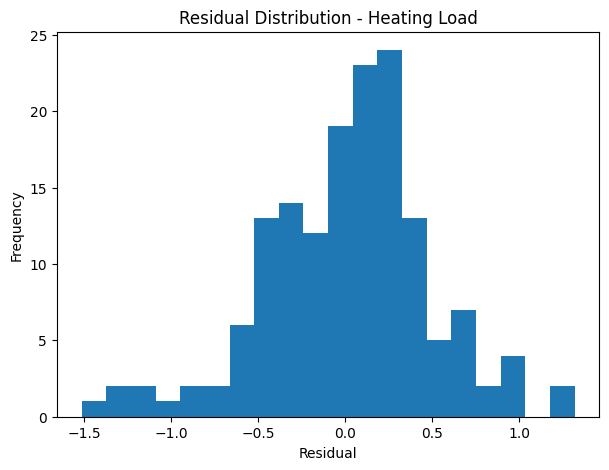

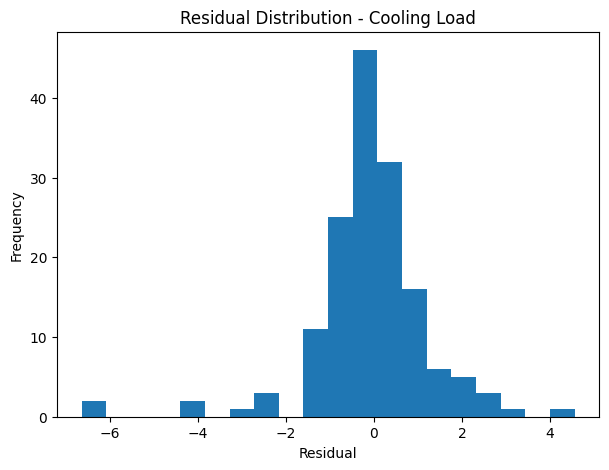

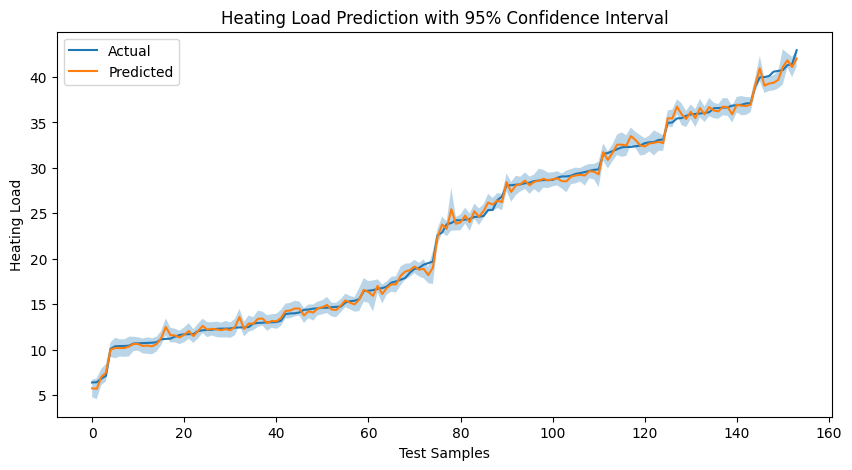

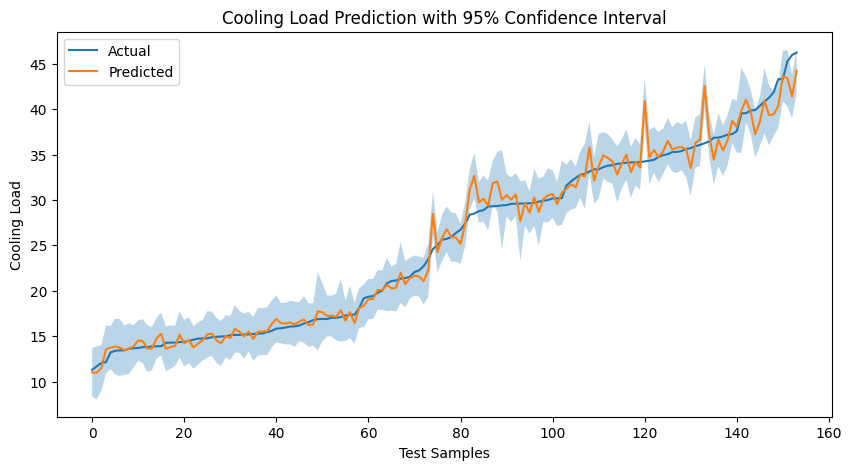

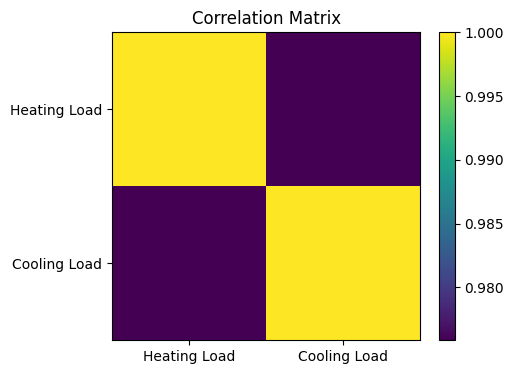


Correlation Matrix
          Y1        Y2
Y1  1.000000  0.975862
Y2  0.975862  1.000000


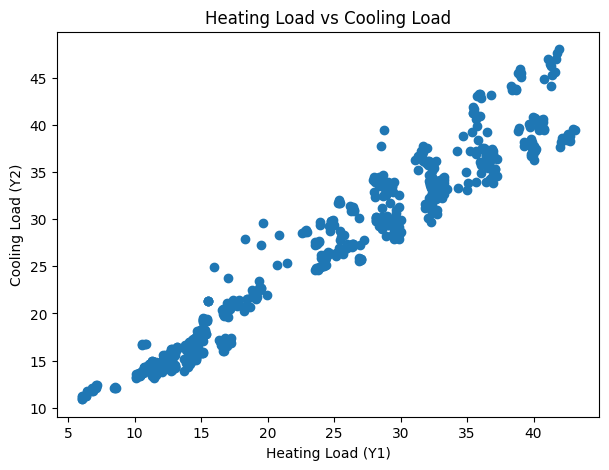

In [4]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error

path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

print("Dataset Path:", path)
print("Files:", os.listdir(path))

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("\nDataset Shape:", df.shape)
print(df.head())

X = df.iloc[:,0:8]
y1 = df.iloc[:,8]
y2 = df.iloc[:,9]

X_train, X_test, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42
)

_, _, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernel = ConstantKernel(1.0,(1e-3,1e3)) * RBF(1.0,(1e-3,1e3)) + WhiteKernel()

gpr_y1 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_y2 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_y1.fit(X_train_scaled,y1_train)
gpr_y2.fit(X_train_scaled,y2_train)

y1_pred,y1_std = gpr_y1.predict(X_test_scaled,return_std=True)
y2_pred,y2_std = gpr_y2.predict(X_test_scaled,return_std=True)

r2_y1 = r2_score(y1_test,y1_pred)
rmse_y1 = np.sqrt(mean_squared_error(y1_test,y1_pred))

r2_y2 = r2_score(y2_test,y2_pred)
rmse_y2 = np.sqrt(mean_squared_error(y2_test,y2_pred))

print("\nHeating Load (Y1)")
print("R² =", round(r2_y1,4))
print("RMSE =", round(rmse_y1,4))

print("\nCooling Load (Y2)")
print("R² =", round(r2_y2,4))
print("RMSE =", round(rmse_y2,4))

plt.figure(figsize=(7,5))
plt.scatter(y1_test,y1_pred)
plt.plot(
    [y1_test.min(),y1_test.max()],
    [y1_test.min(),y1_test.max()]
)
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Actual vs Predicted Heating Load")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y2_test,y2_pred)
plt.plot(
    [y2_test.min(),y2_test.max()],
    [y2_test.min(),y2_test.max()]
)
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Actual vs Predicted Cooling Load")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(y1_test-y1_pred,bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Heating Load")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(y2_test-y2_pred,bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution - Cooling Load")
plt.show()

order1 = np.argsort(np.array(y1_test))

plt.figure(figsize=(10,5))
plt.plot(np.array(y1_test)[order1],label="Actual")
plt.plot(y1_pred[order1],label="Predicted")
plt.fill_between(
    np.arange(len(order1)),
    y1_pred[order1]-1.96*y1_std[order1],
    y1_pred[order1]+1.96*y1_std[order1],
    alpha=0.3
)
plt.xlabel("Test Samples")
plt.ylabel("Heating Load")
plt.title("Heating Load Prediction with 95% Confidence Interval")
plt.legend()
plt.show()

order2 = np.argsort(np.array(y2_test))

plt.figure(figsize=(10,5))
plt.plot(np.array(y2_test)[order2],label="Actual")
plt.plot(y2_pred[order2],label="Predicted")
plt.fill_between(
    np.arange(len(order2)),
    y2_pred[order2]-1.96*y2_std[order2],
    y2_pred[order2]+1.96*y2_std[order2],
    alpha=0.3
)
plt.xlabel("Test Samples")
plt.ylabel("Cooling Load")
plt.title("Cooling Load Prediction with 95% Confidence Interval")
plt.legend()
plt.show()

corr = df.iloc[:,8:10].corr()

plt.figure(figsize=(5,4))
plt.imshow(corr)
plt.xticks([0,1],["Heating Load","Cooling Load"])
plt.yticks([0,1],["Heating Load","Cooling Load"])
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(7,5))
plt.scatter(df.iloc[:,8],df.iloc[:,9])
plt.xlabel("Heating Load (Y1)")
plt.ylabel("Cooling Load (Y2)")
plt.title("Heating Load vs Cooling Load")
plt.show()

Q2

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Dataset Path: /kaggle/input/green-building-multi-source-environment-dataset
Files: ['green_building_dataset.csv']

Dataset Shape: (2400, 19)
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       82

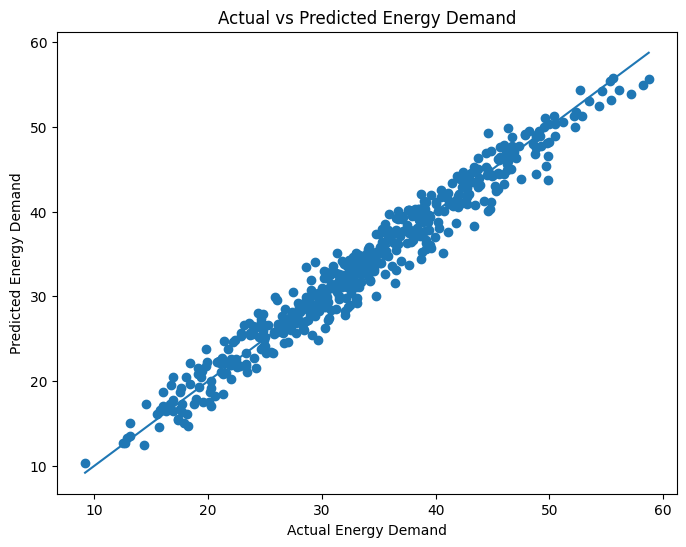

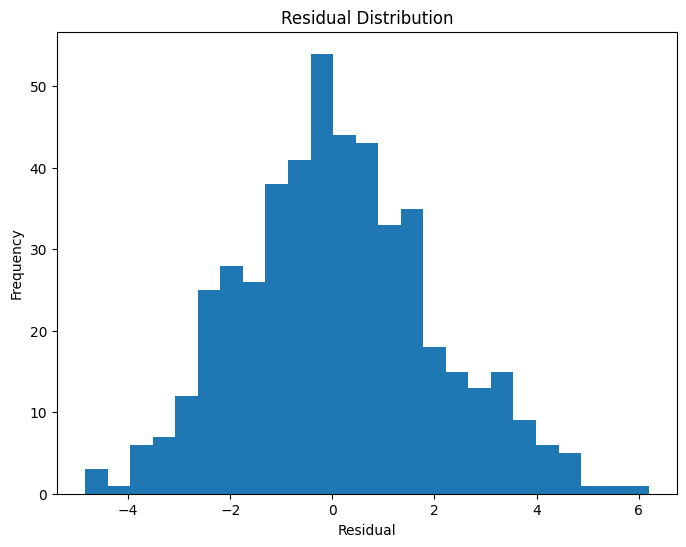

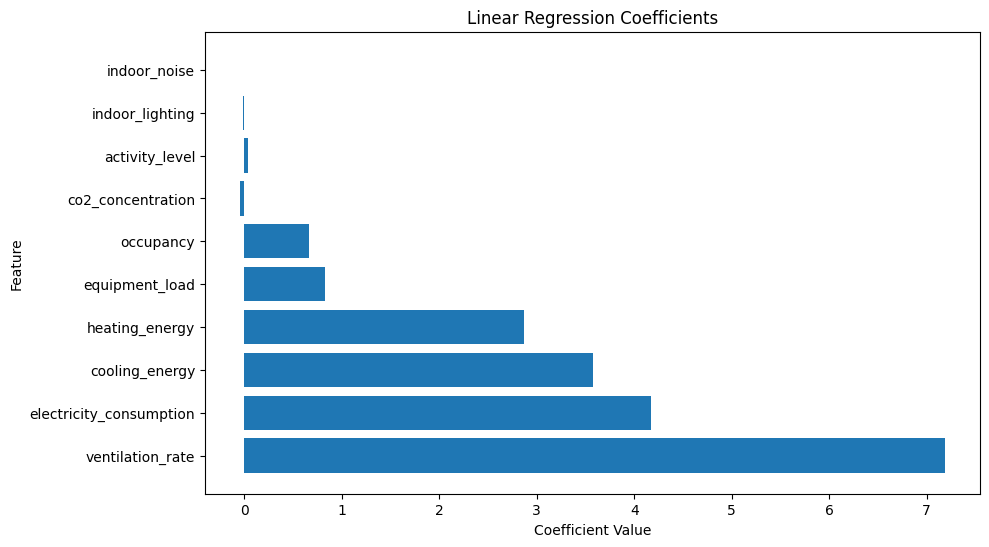

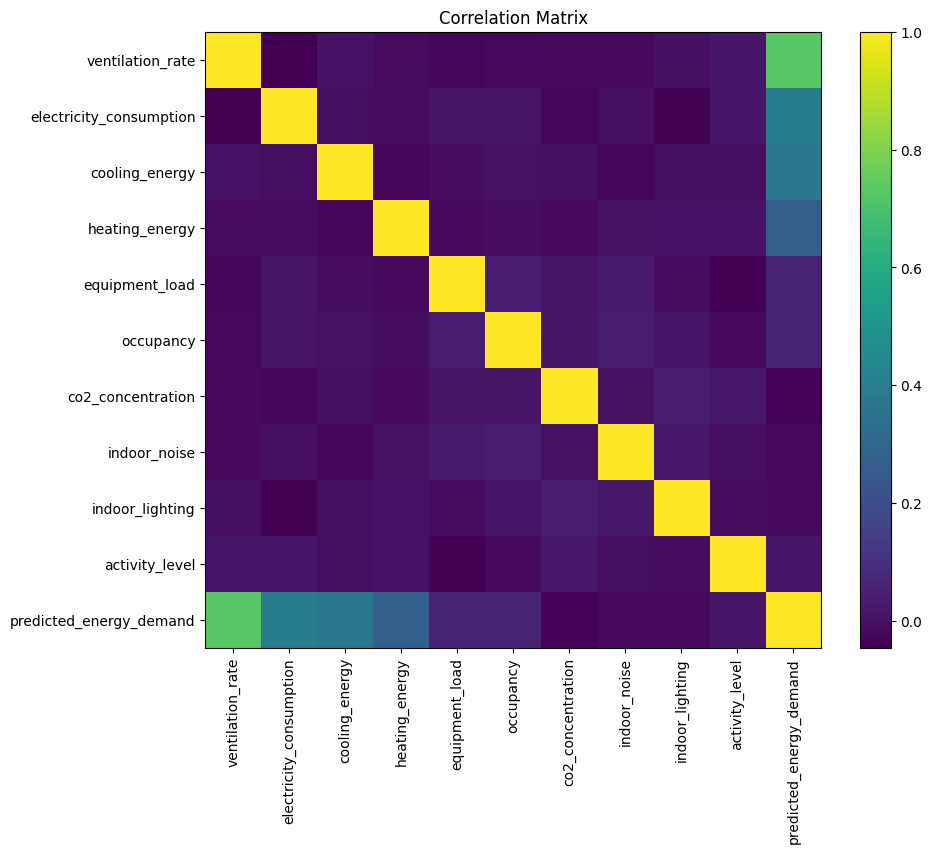

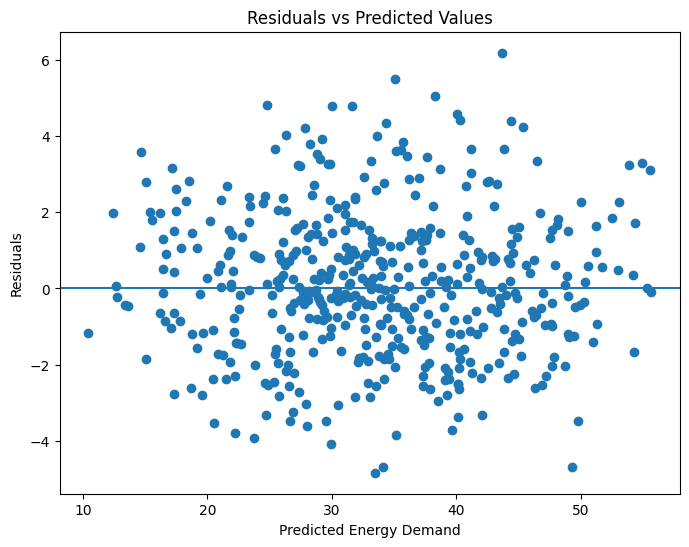

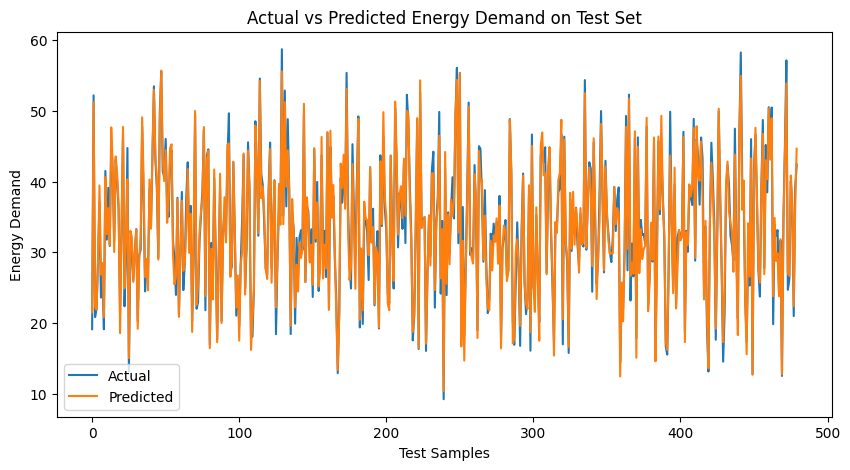

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download(
    "programmer3/green-building-multi-source-environment-dataset"
)

print("Dataset Path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "green_building_dataset.csv"))

print("\nDataset Shape:", df.shape)
print(df.head())

target = "predicted_energy_demand"

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

corr_target = corr_matrix[target].abs().sort_values(ascending=False)

print("\nCorrelation with predicted_energy_demand")
print(corr_target)

selected_features = corr_target.index[1:11].tolist()

print("\nSelected Features")
print(selected_features)

X = numeric_df[selected_features]
y = numeric_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nLinear Regression Results")
print("R² =", round(r2,4))
print("RMSE =", round(rmse,4))

coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print("\nFeature Coefficients")
print(coef_df)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Actual vs Predicted Energy Demand")
plt.show()

plt.figure(figsize=(8,6))
plt.hist(y_test - y_pred, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(10,6))
plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.show()

plt.figure(figsize=(10,8))
plt.imshow(
    corr_matrix.loc[selected_features + [target],
                    selected_features + [target]]
)
plt.colorbar()
plt.xticks(
    range(len(selected_features)+1),
    selected_features + [target],
    rotation=90
)
plt.yticks(
    range(len(selected_features)+1),
    selected_features + [target]
)
plt.title("Correlation Matrix")
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Energy Demand")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(np.arange(len(y_test)), y_test.values, label="Actual")
plt.plot(np.arange(len(y_test)), y_pred, label="Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Energy Demand")
plt.title("Actual vs Predicted Energy Demand on Test Set")
plt.legend()
plt.show()